In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.0 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model = YOLO("yolov8n.pt")
model.train(
    data="/content/drive/MyDrive/Capstone/Final_dataset_2/Data.yaml",
    epochs=200,
    pretrained=True,
    imgsz=640,   # Pi 5 can handle 640
    batch=32,
    device=0,
    lr0=0.001,
    degrees=0.0,     # no rotation
    flipud=0.0,      # no vertical flip
    fliplr=0.5,
    mosaic=1.0,
    copy_paste=0.3,
    patience=50
)

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Capstone/Final_dataset_2/Data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimize

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bbed0076cf0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
results = model.val()

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 15.0±15.4 MB/s, size: 18.7 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1qT9Ux_AI-lTbLxkwQe0rK6d_UPgp2Uid/Capstone/Final_dataset_2/labels/valid.cache... 446 images, 195 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 601/601 193.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 7.9it/s 4.8s
                   all        601        445      0.939      0.909       0.97      0.781
             Stop Sign        235        248      0.975      0.968      0.993      0.805
      Speed Limit Sign        171        197      0.903       0.85      0.947      0.757
Speed: 0.7ms preprocess, 1.6ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /content/runs/detect/val


In [ ]:
success = model.export(format="tflite")

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/train5/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (6.0 MB)
requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnx>=1.12.0,<2.0.0', 'onnx2tf>=1.26.3,<1.29.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 18 packages in 8.01s
Prepared 9 packages in 3.37s
Installed 9 packages in 308ms
 + ai-edge-litert==2.1.4
 + backports-strenum==1.3.1
 + colorama==0.4.6
 + onnx==1.21.0
 + onnx-graphsurgeon==0.6.1
 + onnx2tf==1.28.8
 + onnxruntime-gpu==1.24.4
 + onnxsli

In [ ]:
import os
import glob

# ── Paths — adjust if yours are different ──────────────
train_labels = "/content/drive/MyDrive/Capstone/Final_dataset_2/labels/train"
val_labels   = "/content/drive/MyDrive/Capstone/Final_dataset_2/labels/valid"

# ── Class IDs from your data.yaml ──────────────────────
# 0 = Stop Sign, 1 = Speed Limit Sign

def count_instances(labels_dir):
    stop_sign   = 0
    speed_limit = 0
    total_files = 0
    empty_files = 0

    # Define a mapping from string class names to integer IDs
    class_name_map = {
        'Stop': 0, # Map 'Stop' to 0 for 'Stop Sign'
        'Speed': 1 # Map 'Speed' to 1 for 'Speed Limit Sign'
    }

    for label_file in glob.glob(f"{labels_dir}/*.txt"):
        total_files += 1
        with open(label_file, 'r') as f:
            lines = f.readlines()
            if not lines:
                empty_files += 1
            for line in lines:
                parts = line.strip().split()
                if not parts: # Skip empty lines
                    continue

                first_part = parts[0]
                cls = None

                try:
                    cls = int(first_part)
                except ValueError:
                    # If it's not a number, check if it's a known class name string
                    if first_part in class_name_map:
                        cls = class_name_map[first_part]
                    else:
                        print(f"Warning: Could not parse class ID from '{first_part}' in file '{label_file}'. Skipping line.")
                        continue # Skip line if class ID is neither int nor mapped string

                if cls == 0:
                    stop_sign += 1
                elif cls == 1:
                    speed_limit += 1

    return {
        "total_label_files" : total_files,
        "empty_files"       : empty_files,
        "stop_sign"         : stop_sign,
        "speed_limit"       : speed_limit,
        "total_instances"   : stop_sign + speed_limit
    }

print("── TRAIN ──────────────────────────")
train = count_instances(train_labels)
for k, v in train.items():
    print(f"  {k:<25} {v}")

print("\n── VAL ────────────────────────────")
val = count_instances(val_labels)
for k, v in val.items():
    print(f"  {k:<25} {v}")

print("\n── TOTAL ──────────────────────────")
print(f"  {'stop_sign':<25} {train['stop_sign']   + val['stop_sign']}")
print(f"  {'speed_limit':<25} {train['speed_limit'] + val['speed_limit']}")
print(f"  {'total_instances':<25} {train['total_instances'] + val['total_instances']}")

── TRAIN ──────────────────────────
  total_label_files         2176
  empty_files               173
  stop_sign                 880
  speed_limit               1279
  total_instances           2159

── VAL ────────────────────────────
  total_label_files         601
  empty_files               40
  stop_sign                 252
  speed_limit               382
  total_instances           634

── TOTAL ──────────────────────────
  stop_sign                 1132
  speed_limit               1661
  total_instances           2793


### Test Model on Random Images

In [ ]:
import os
import random
from glob import glob
from IPython.display import Image, display

# Define paths
model_path = '/content/runs/detect/train/weights/best.pt' # Path to your trained model
test_images_dir = '/content/drive/MyDrive/Capstone/Final_dataset_2/images/test' # Path to your test images

# Load the trained model
model = YOLO(model_path)

# Get a list of all image files in the test directory
image_files = glob(os.path.join(test_images_dir, '*.jpg')) + \
              glob(os.path.join(test_images_dir, '*.jpeg')) + \
              glob(os.path.join(test_images_dir, '*.png'))

# Ensure there are enough images to select from
if len(image_files) < 10:
    print(f"Warning: Only {len(image_files)} test images found. Displaying all available images.")
    num_images_to_display = len(image_files)
else:
    num_images_to_display = 10

# Select a random subset of images
random_test_images = random.sample(image_files, num_images_to_display)

print(f"Running inference on {num_images_to_display} random test images...")


Running inference on 10 random test images...



0: 640x640 1 Speed Limit Sign, 6.8ms
1: 640x640 (no detections), 6.8ms
2: 640x640 1 Stop Sign, 6.8ms
3: 640x640 (no detections), 6.8ms
4: 640x640 1 Stop Sign, 6.8ms
5: 640x640 2 Stop Signs, 6.8ms
6: 640x640 1 Speed Limit Sign, 6.8ms
7: 640x640 1 Stop Sign, 6.8ms
8: 640x640 1 Speed Limit Sign, 6.8ms
9: 640x640 1 Speed Limit Sign, 6.8ms
Speed: 2.7ms preprocess, 6.8ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
Predicted images saved to: /content/runs/detect/predict

Displaying predicted images:


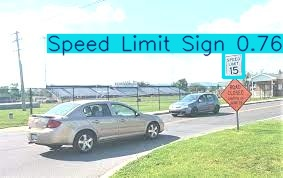

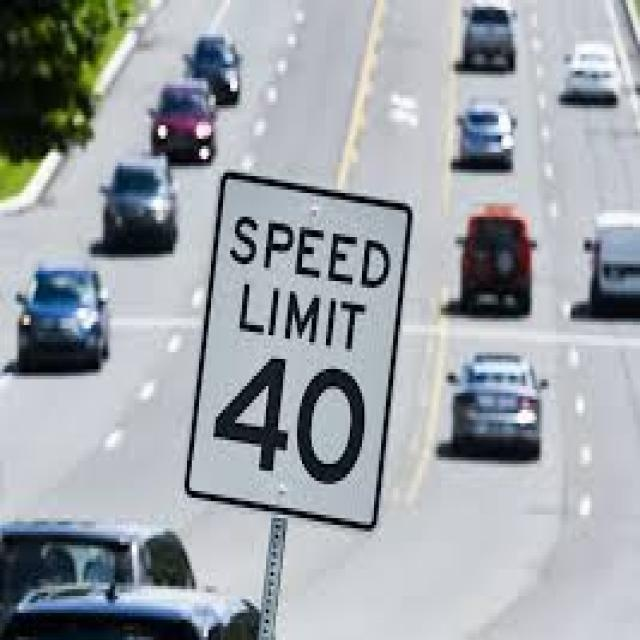

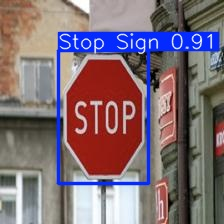

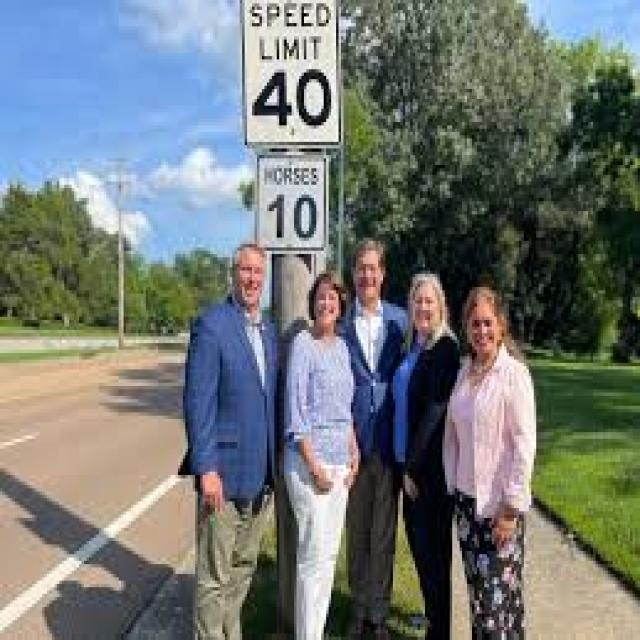

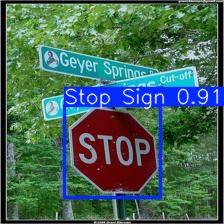

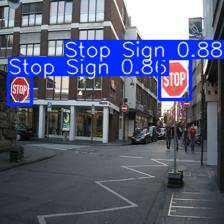

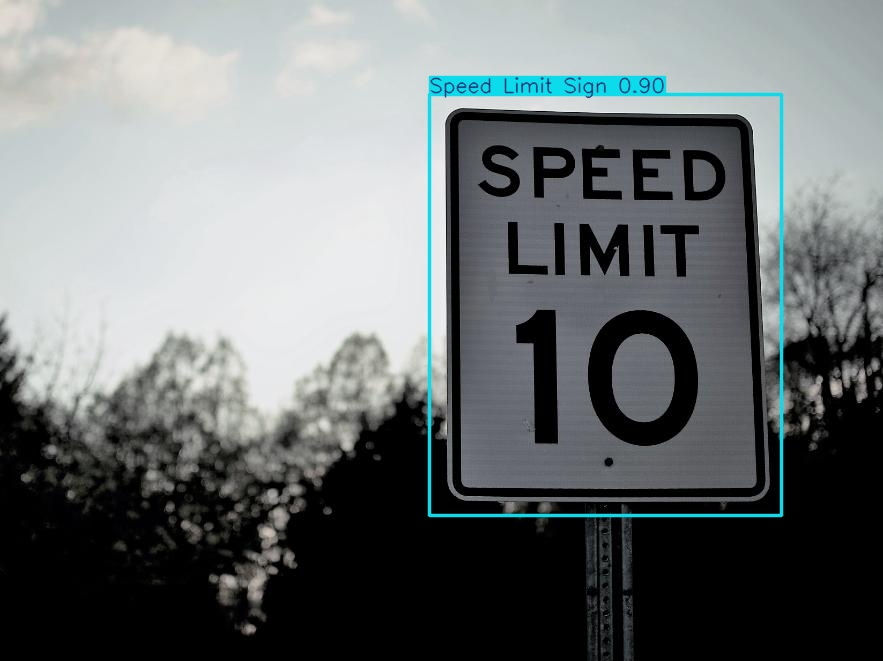

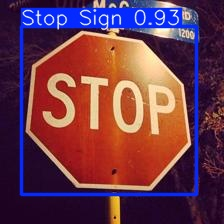

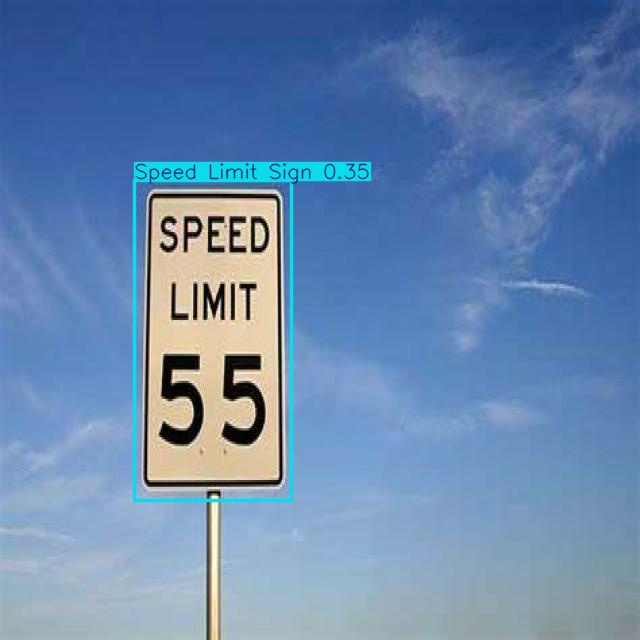

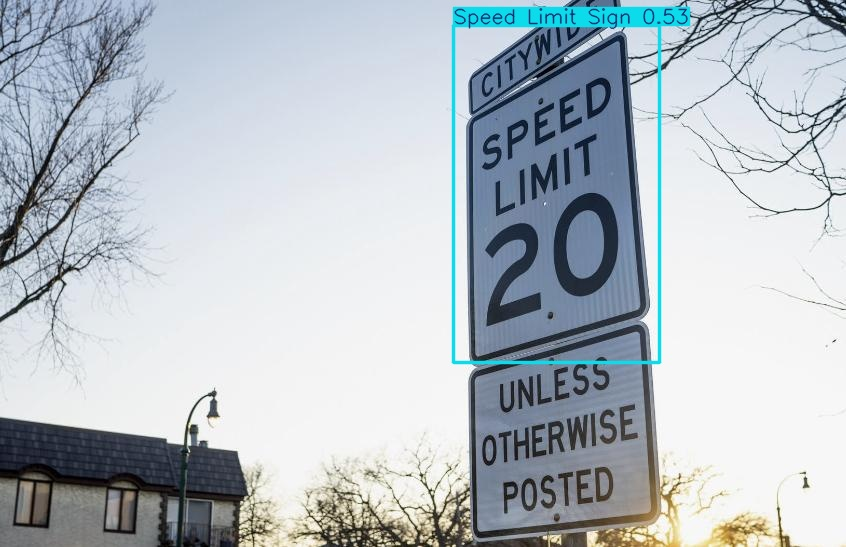

In [ ]:
# Run inference and save results
# The 'save=True' argument will save the predicted images with bounding boxes
results = model.predict(source=random_test_images, save=True, imgsz=640)

# Get the directory where the results were saved
# The predict function usually creates a new 'predict' folder (e.g., 'runs/detect/predict', 'runs/detect/predict2', etc.)
# We need to find the latest one.
runs_dir = os.path.join(model.predictor.save_dir)
predicted_images_dir = runs_dir

print(f"Predicted images saved to: {predicted_images_dir}")

# Display the predicted images
print("\nDisplaying predicted images:")
for r in results:
    # r.path is the original image path
    # The predicted image with boxes is saved in the results directory
    # The filename should be the same as the original, but in the new directory
    predicted_image_name = os.path.basename(r.path)
    predicted_image_path = os.path.join(predicted_images_dir, predicted_image_name)
    if os.path.exists(predicted_image_path):
        display(Image(filename=predicted_image_path, width=600))
    else:
        print(f"Could not find predicted image: {predicted_image_path}")